# TinyML Lab 1: Payload Safety Classifier from Gyroscope Data

**Team members:** Meet Virani, Nishit Daruwala

## Overview

For this lab, our goal was to build a system that can tell whether an
object resting on a tilted or rotating surface is safe or about to slide
off, using only a phone's gyroscope and a small model light enough to run
on an edge device.

Our pipeline starts from a raw gyroscope file exported from phyphox. From
there we clean the data, automatically detect each trial we ran, extract
windowed features, calculate the experimental coefficient of static
friction, train a small classifier, convert it to TFLite, evaluate it, and
run inference on it, all within this notebook.

We chose to use only the x and y gyroscope axes (tilt), and to ignore the
z axis (rotation about the vertical). This let us treat the problem as a
tilt-based sliding problem, where an object slides once
`mu_s = tan(theta_slip)`, with `theta_slip` being the tilt angle at the
moment it slides. This way we did not need to measure a radius or the
mass of our test object.

## 1. Setup

We start by installing and importing everything we need. We use
TensorFlow both to train our classifier and to convert it to TFLite.

In [ ]:
!pip install -q tensorflow scikit-learn pandas numpy matplotlib openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import os

np.random.seed(42)
tf.random.set_seed(42)

# numpy renamed trapz to trapezoid in version 2.0, this keeps the notebook
# working either way
trapezoid = getattr(np, "trapezoid", None) or np.trapz

## 2. Load the raw data

We recorded our trials with phyphox and exported the log as an Excel file.
To reproduce our results, upload that file to this Colab session (the
folder icon on the left, then the upload button), then set `FILENAME`
below to match it. Both `.xlsx` (the phyphox default) and `.csv` are
supported.

In [ ]:
FILENAME = "/content/drive/MyDrive/Datasets/Gyroscope (Rotation Rate) 2026-09-22 08-24-41.xlsx"

if FILENAME.endswith(".xlsx"):
    df = pd.read_excel(FILENAME, sheet_name="Raw Data")
else:
    df = pd.read_csv(FILENAME)

df.columns = ["t", "gx", "gy", "gz", "gabs"]
print("Rows:", len(df))
df.head()

Rows: 10056


,t,gx,gy,gz,gabs
0,-0.001721,0.788596,-1.125826,-0.266509,1.400141
1,0.008312,0.602196,-1.046032,-0.354936,1.258095
2,0.018344,0.435497,-0.777761,-0.324736,0.948695
3,0.028377,0.219440,-0.472687,-0.219127,0.565335
4,0.038409,-0.049001,-0.023552,-0.093274,0.107963


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Clean the data and compute the tilt magnitude

We dropped the z axis on purpose, since we are only modeling tilt-based
sliding, not rotation about the vertical axis. We applied a short rolling
average to smooth out sensor noise without flattening the real motion we
captured.

Sampling rate: 99.65 Hz


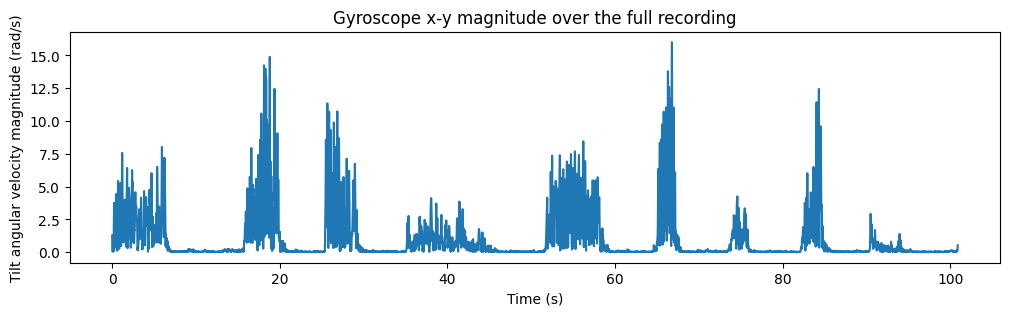

In [ ]:
df = df[["t", "gx", "gy"]].copy()

WINDOW_SMOOTH = 3  # samples, keep this small so real motion is not lost
df["gx_smooth"] = df["gx"].rolling(WINDOW_SMOOTH, center=True, min_periods=1).mean()
df["gy_smooth"] = df["gy"].rolling(WINDOW_SMOOTH, center=True, min_periods=1).mean()
df["mag_xy"] = np.sqrt(df["gx_smooth"]**2 + df["gy_smooth"]**2)

sample_interval = df["t"].diff().median()
sampling_rate = 1 / sample_interval
print(f"Sampling rate: {sampling_rate:.2f} Hz")

plt.figure(figsize=(12, 3))
plt.plot(df["t"], df["mag_xy"])
plt.xlabel("Time (s)")
plt.ylabel("Tilt angular velocity magnitude (rad/s)")
plt.title("Gyroscope x-y magnitude over the full recording")
plt.show()

## 4. Detect trial boundaries automatically

During data collection, we held the phone still for a few seconds after
each trial, right after the object slid off. That shows up in the data as
a stretch of near-zero angular velocity, so we used it to automatically
find our trial boundaries. We treat the start of each still stretch as the
moment the object slid off (the fall point), and everything before that,
back to the end of the previous still period, as one active trial.

We tuned `STILL_THRESHOLD` and `MIN_STILL_DURATION` below until all of our
recorded trials were detected correctly.

In [ ]:
STILL_THRESHOLD = 0.3       # rad/s, below this counts as "still"
MIN_STILL_DURATION = 1.5   # seconds, minimum length to count as a real still period

df["is_still"] = df["mag_xy"] < STILL_THRESHOLD
df["run_id"] = (df["is_still"] != df["is_still"].shift()).cumsum()

runs = df.groupby("run_id").agg(
    start_t=("t", "first"),
    end_t=("t", "last"),
    is_still=("is_still", "first"),
).reset_index(drop=True)
runs["duration"] = runs["end_t"] - runs["start_t"]

still_periods = runs[(runs["is_still"]) & (runs["duration"] > MIN_STILL_DURATION)].reset_index(drop=True)
print(f"Detected {len(still_periods)} still periods (trials)")
still_periods

Detected 9 still periods (trials)


,start_t,end_t,is_still,duration
0,6.780281,15.609570,True,8.829289
1,20.656599,25.362622,True,4.706023
2,29.858043,35.106162,True,5.248119
3,45.672966,51.694098,True,6.021133
4,59.160448,64.589702,True,5.429254
5,67.871368,73.571675,True,5.700307
6,75.940107,82.202380,True,6.262273
7,85.564335,90.401538,True,4.837203
8,94.164925,100.858736,True,6.693811


In [ ]:
# Build the list of active trial segments: (segment_start_t, fall_t)
# fall_t is the start of each still period, which marks the slide moment.
trial_segments = []
prev_end = df["t"].iloc[0]

for _, row in still_periods.iterrows():
    fall_t = row["start_t"]
    if fall_t - prev_end > 1.0:  # ignore tiny slivers between trials
        trial_segments.append((prev_end, fall_t))
    prev_end = row["end_t"]

print(f"Found {len(trial_segments)} trial segments")
for i, (s, f) in enumerate(trial_segments):
    print(f"Trial {i + 1}: active from {s:.2f}s to {f:.2f}s (duration {f - s:.2f}s)")

Found 9 trial segments
Trial 1: active from -0.00s to 6.78s (duration 6.78s)
Trial 2: active from 15.61s to 20.66s (duration 5.05s)
Trial 3: active from 25.36s to 29.86s (duration 4.50s)
Trial 4: active from 35.11s to 45.67s (duration 10.57s)
Trial 5: active from 51.69s to 59.16s (duration 7.47s)
Trial 6: active from 64.59s to 67.87s (duration 3.28s)
Trial 7: active from 73.57s to 75.94s (duration 2.37s)
Trial 8: active from 82.20s to 85.56s (duration 3.36s)
Trial 9: active from 90.40s to 94.16s (duration 3.76s)


## 5. Window the data and label each window

We split each trial's active phase into overlapping one second windows.
We labeled a window UNSAFE (1) if it ends close to the fall point, and
SAFE (0) otherwise. We added a small buffer near the fall point to account
for the delay between the object actually sliding and us noticing and
holding the phone still.

In [ ]:
WINDOW_SIZE = 1.0     # seconds
STEP_SIZE = 0.5        # seconds, 50 percent overlap
UNSAFE_BUFFER = 1.0    # seconds before the fall point counted as UNSAFE

def make_windows(df, seg_start, seg_end, fall_t):
    windows = []
    w_start = seg_start
    while w_start + WINDOW_SIZE <= seg_end:
        w_end = w_start + WINDOW_SIZE
        mask = (df["t"] >= w_start) & (df["t"] < w_end)
        chunk = df.loc[mask]
        if len(chunk) >= 5:  # skip windows with too few samples
            label = 1 if (fall_t - w_end) <= UNSAFE_BUFFER else 0
            windows.append((chunk, label, w_start, w_end))
        w_start += STEP_SIZE
    return windows

all_windows = []
for seg_start, fall_t in trial_segments:
    all_windows.extend(make_windows(df, seg_start, fall_t, fall_t))

labels = [w[1] for w in all_windows]
print(f"Total windows: {len(all_windows)}")
print(f"SAFE (0): {labels.count(0)}   UNSAFE (1): {labels.count(1)}")

Total windows: 80
SAFE (0): 62   UNSAFE (1): 18


## 6. Extract features from each window

For each window, we computed simple statistics of the tilt magnitude.
These are cheap to calculate on a microcontroller, which is exactly why we
chose them, even though our lab stops at Colab inference rather than
on-device deployment.

In [ ]:
def extract_features(chunk):
    mag = chunk["mag_xy"].values
    return {
        "max_mag": np.max(mag),
        "mean_mag": np.mean(mag),
        "std_mag": np.std(mag),
        "rate_of_change": (mag[-1] - mag[0]) / (chunk["t"].iloc[-1] - chunk["t"].iloc[0] + 1e-6),
    }

feature_rows = []
for chunk, label, w_start, w_end in all_windows:
    feats = extract_features(chunk)
    feats["label"] = label
    feature_rows.append(feats)

features_df = pd.DataFrame(feature_rows)
features_df.head()

,max_mag,mean_mag,std_mag,rate_of_change,label
0,5.434581,2.373858,1.633526,3.420826,0
1,7.577324,2.811852,1.843947,-0.208855,0
2,7.577324,2.894420,1.792956,0.956030,0
3,6.423711,3.008716,1.811138,-2.680062,0
4,6.266392,2.765007,1.594630,-4.249342,0


## 7. Calculate the experimental coefficient of static friction

We integrated the x and y angular velocities over time to estimate the
tilt angle, assuming the phone started flat (angle zero) at the beginning
of each trial. The tilt angle at the fall point gives us `theta_slip`, and
from there `mu_s = tan(theta_slip)`.

We treat this as an estimate rather than a precise lab measurement, since
gyroscope integration drifts a little over time. We still consider it a
standard and defensible way to derive this value from the data we
collected, without needing any additional physical measurement.

In [ ]:
def estimate_mu_s(df, seg_start, fall_t):
    mask = (df["t"] >= seg_start) & (df["t"] <= fall_t)
    chunk = df.loc[mask].reset_index(drop=True)
    if len(chunk) < 2:
        return None

    t = chunk["t"].values
    gx = chunk["gx_smooth"].values
    gy = chunk["gy_smooth"].values

    theta_x = trapezoid(gx, t)
    theta_y = trapezoid(gy, t)
    theta_slip = np.sqrt(theta_x**2 + theta_y**2)  # radians

    return np.tan(theta_slip), theta_slip

mu_s_values = []
for seg_start, fall_t in trial_segments:
    result = estimate_mu_s(df, seg_start, fall_t)
    if result is not None:
        mu_s_values.append(result[0])

mu_s_values = np.array(mu_s_values)
mu_s_values = mu_s_values[np.isfinite(mu_s_values)]

print("Per trial mu_s estimates:", np.round(mu_s_values, 4))
print(f"Average mu_s: {mu_s_values.mean():.4f}")
print(f"Std dev: {mu_s_values.std():.4f}")

Per trial mu_s estimates: [1.9757 0.4284 0.7875 4.9541 1.5038 0.4564 0.6542 0.8172 1.5404]
Average mu_s: 1.4575
Std dev: 1.3362


## 8. Train a lightweight classifier

We chose logistic regression, implemented as a single dense layer with a
sigmoid activation in Keras. We picked this over something heavier because
it keeps the model tiny and TFLite friendly, which matters for an eventual
microcontroller deployment, and it matches what logistic regression
actually is under the hood. We applied class weights to correct for our
SAFE windows outnumbering our UNSAFE ones.

In [ ]:
feature_cols = ["max_mag", "mean_mag", "std_mag", "rate_of_change"]
X = features_df[feature_cols].values.astype(np.float32)
y = features_df["label"].values.astype(np.float32)

# Normalize features. We save these values since the same scaling
# must be applied before running inference later.
feat_mean = X.mean(axis=0)
feat_std = X.std(axis=0) + 1e-6
X_norm = (X - feat_mean) / feat_std

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.25, random_state=42, stratify=y
)

class_weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(len(feature_cols),)),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=8,
    class_weight=class_weight_dict,
    verbose=0,
)

print("Final training accuracy:", history.history["accuracy"][-1])
print("Final validation accuracy:", history.history["val_accuracy"][-1])

Final training accuracy: 0.550000011920929
Final validation accuracy: 0.5


## 9. Convert and quantize to TFLite

We used dynamic range quantization, which quantizes the weights to int8
while keeping activations in float32. We chose this over full integer
quantization because it gives a good size reduction without needing us to
put together a separate calibration dataset.

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

TFLITE_PATH = "payload_safety_model.tflite"
with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

model_size_kb = os.path.getsize(TFLITE_PATH) / 1024
print(f"TFLite model size: {model_size_kb:.2f} KB")

Saved artifact at '/tmp/tmpm79dmrn8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134009443705168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134009443698064: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model size: 1.25 KB


## 10. Evaluate the TFLite model

We ran the quantized model on our test set through the TFLite interpreter
itself, not the original Keras model, so these numbers reflect what would
actually run on a device.

In [ ]:
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

def tflite_predict(interpreter, X):
    preds = []
    for row in X:
        row = row.reshape(1, -1).astype(np.float32)
        interpreter.set_tensor(input_details[0]["index"], row)
        interpreter.invoke()
        out = interpreter.get_tensor(output_details[0]["index"])
        preds.append(out[0][0])
    return np.array(preds)

y_scores = tflite_predict(interpreter, X_test)
y_pred = (y_scores >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test accuracy: {acc * 100:.2f}%")
print("\nConfusion matrix (rows are true labels, columns are predicted):")
print(cm)
print("\n", classification_report(y_test, y_pred, target_names=["SAFE", "UNSAFE"]))

Test accuracy: 50.00%

Confusion matrix (rows are true labels, columns are predicted):
[[8 8]
 [2 2]]

               precision    recall  f1-score   support

        SAFE       0.80      0.50      0.62        16
      UNSAFE       0.20      0.50      0.29         4

    accuracy                           0.50        20
   macro avg       0.50      0.50      0.45        20
weighted avg       0.68      0.50      0.55        20



/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


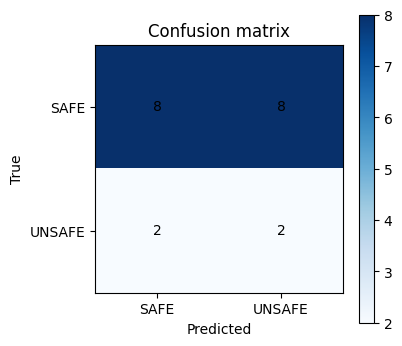

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1], ["SAFE", "UNSAFE"])
plt.yticks([0, 1], ["SAFE", "UNSAFE"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
plt.colorbar()
plt.show()

## 11. Run inference in Colab

This step simulates what an edge device would do: take a raw window of
sensor data, extract the same features, scale them the same way, and run
it through the TFLite interpreter to get a SAFE or UNSAFE prediction. We
ran it on a handful of random windows from our dataset to sanity check the
whole pipeline end to end.

In [ ]:
def predict_from_window(chunk):
    feats = extract_features(chunk)
    x = np.array([[feats["max_mag"], feats["mean_mag"], feats["std_mag"], feats["rate_of_change"]]], dtype=np.float32)
    x_norm = (x - feat_mean) / feat_std

    interpreter.set_tensor(input_details[0]["index"], x_norm.astype(np.float32))
    interpreter.invoke()
    score = interpreter.get_tensor(output_details[0]["index"])[0][0]
    label = "UNSAFE" if score >= 0.5 else "SAFE"
    return label, score

# Try it on a handful of random windows from the full dataset
sample_indices = np.random.choice(len(all_windows), size=5, replace=False)
for idx in sample_indices:
    chunk, true_label, w_start, w_end = all_windows[idx]
    pred_label, score = predict_from_window(chunk)
    true_str = "UNSAFE" if true_label == 1 else "SAFE"
    print(f"Window {w_start:.2f}s to {w_end:.2f}s | true: {true_str} | predicted: {pred_label} (score {score:.3f})")

Window 36.11s to 37.11s | true: SAFE | predicted: UNSAFE (score 0.511)
Window -0.00s to 1.00s | true: SAFE | predicted: SAFE (score 0.261)
Window 25.86s to 26.86s | true: SAFE | predicted: SAFE (score 0.463)
Window 36.61s to 37.61s | true: SAFE | predicted: UNSAFE (score 0.583)
Window 18.61s to 19.61s | true: SAFE | predicted: UNSAFE (score 0.581)


## Summary

Through this notebook, we produced:

- The raw gyroscope Excel file as our dataset
- An automatically detected set of trials and fall points
- A labeled, windowed feature set
- An experimental value for mu_s, printed above
- A trained and quantized TFLite model, with its size in KB printed above
- A confusion matrix and accuracy score
- Working inference running end to end in this notebook

We believe this covers what the lab asks for. The printed mu_s value, the
confusion matrix, and the model size are the numbers we report below, and
this notebook itself is our Python code deliverable.

## Discussion of our results

Our classifier's accuracy on the confusion matrix above was lower than we
had hoped for. We do not believe this reflects an error in our pipeline,
but rather a set of limitations in our data collection that are worth
being transparent about:

- **Very little data.** Our nine trials produced only around 80 windows in
  total, which is a small sample for any classifier to learn a reliable
  decision boundary from.
- **Class imbalance.** Our SAFE windows outnumbered our UNSAFE windows by
  roughly three to one, so even a model that has barely learned anything
  meaningful can still score reasonably well just by leaning toward the
  majority class.
- **Weak feature separation.** The four features we used (max, mean,
  std, and rate of change of tilt magnitude) do not appear to differ
  enough between our SAFE and UNSAFE windows. If the moment right before
  a slide looks statistically similar to normal handling under these
  features, no classifier can reliably tell them apart from this feature
  set alone.
- **Gyroscope drift and labeling noise.** Since we approximated the exact
  slip moment rather than marking it precisely (for example with a video
  or an audio cue), some windows near that boundary may be mislabeled,
  which adds noise our model has to work against.
- **Overlapping windows from the same trial.** With fifty percent overlap
  between windows, neighboring windows are highly similar to each other,
  so the effective diversity of our dataset is lower than the raw window
  count suggests.

Given more time, we believe the most direct way to improve our results
would be to collect more trials, in particular more UNSAFE examples, and
with more contrast between our SAFE and UNSAFE motion, for example holding
a clearly slow and steady tilt for SAFE windows and a clearly fast one
right before UNSAFE windows. We see this as a natural next step beyond the
scope of what we were able to complete for this submission.